<br>
<div class= 'alert alert-block alert-danger'>
<b>

### Exploratory Data Analysis on Climate Trace Emission Dataset
#### - Madhur Devkota (04/02/2024)
</b>
<p>
</div>

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pathlib

%matplotlib inline
np.random.seed(1)
pd.set_option('display.max_columns', None)
# plt.style.use('seaborn-v0_8-darkgrid')
#3 dark mode
plt.style.use( 'dark_background' )
# plt.style.available
sns.set_context('talk')


## Power Emissions EDA

Goals: load the processed power dataset, derive `year` from `start_time`, drop date columns (including `modified_date` to avoid leakage), and run target-centric, feature, temporal, and geospatial EDA aligned to future ML on `emissions_quantity`. Paths stay relative for portability.

In [2]:
PROJECT_ROOT = pathlib.Path.cwd().parent
GEO_DATA_DIRPATH =  PROJECT_ROOT  / 'data' / 'supporting_dataset' / 'US_State_geo'
shpfile_path = GEO_DATA_DIRPATH / 'cb_2016_us_state_5m.shp'
usa_gdf = gpd.read_file(shpfile_path)
data_path = PROJECT_ROOT / 'data' / 'processed' / 'processed_data.csv'

In [3]:
df_raw = pd.read_csv(data_path)
date_cols = ['start_time', 'end_time', 'modified_date']
for col in date_cols:
    if col in df_raw.columns:
        df_raw[col] = pd.to_datetime(df_raw[col], errors='coerce')

df_raw['year'] = df_raw['start_time'].dt.year
drop_cols = [c for c in ['start_time', 'end_time', 'modified_date'] if c in df_raw.columns]
df = df_raw.drop(columns=drop_cols)
for cat_col in ['source_type', 'state']:
    if cat_col in df.columns:
        df[cat_col] = df[cat_col].astype('category')

print('Loaded shape:', df.shape)
df.head()

Loaded shape: (8849, 10)


,emissions_quantity,emissions_factor,capacity,capacity_factor,activity,source_type,state,area,pop2020,year
0,214000.0,0.513,138.0,0.345,417000.0,gas,Alabama,12.899239,5024279.0,2022
1,204000.0,0.513,138.0,0.329,398000.0,gas,Alabama,12.899239,5024279.0,2019
2,209000.0,0.515,138.0,0.335,406000.0,gas,Alabama,12.899239,5024279.0,2020
3,201000.0,0.513,138.0,0.324,392000.0,gas,Alabama,12.899239,5024279.0,2021
4,113000.0,0.452,87.0,0.328,250000.0,gas,Texas,65.363350,29145505.0,2019


In [4]:
# Data quality: dtypes, missingness, duplicates, start/end consistency
dtypes = df_raw.dtypes
missing_pct = df_raw.isna().mean().sort_values(ascending=False) * 100
dup_count = df_raw.duplicated().sum()
start_end_mismatch = None
if {'start_time', 'end_time'}.issubset(df_raw.columns):
    start_end_mismatch = (df_raw.start_time.dt.year != df_raw.end_time.dt.year).sum()

print('Dtypes:\n', dtypes)
print('\nMissing % by column (top 10):')
print(missing_pct.head(10))
print(f"\nDuplicate rows: {dup_count}")
if start_end_mismatch is not None:
    print(f"Start/end year mismatches: {start_end_mismatch}")
df_raw.describe(include='all')

Dtypes:
 start_time            datetime64[ns]
end_time              datetime64[ns]
emissions_quantity           float64
emissions_factor             float64
capacity                     float64
capacity_factor              float64
activity                     float64
modified_date         datetime64[ns]
source_type                   object
state                         object
area                         float64
pop2020                      float64
year                           int32
dtype: object

Missing % by column (top 10):
start_time            0.0
end_time              0.0
emissions_quantity    0.0
emissions_factor      0.0
capacity              0.0
capacity_factor       0.0
activity              0.0
modified_date         0.0
source_type           0.0
state                 0.0
dtype: float64

Duplicate rows: 512
Start/end year mismatches: 0


,start_time,end_time,emissions_quantity,emissions_factor,capacity,capacity_factor,activity,modified_date,source_type,state,area,pop2020,year
count,8849,8849,8.849000e+03,8849.000000,8849.000000,8849.000000,8.849000e+03,8849,8849,8849,8849.000000,8.849000e+03,8849.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,49,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gas,California,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5917,806,NaN,NaN,NaN
mean,2020-06-25 11:54:52.439823616,2021-06-24 17:56:27.637021184,8.188977e+05,0.555308,432.930049,0.326641,1.349288e+06,2023-11-01 10:00:00,NaN,NaN,21.620055,1.284123e+07,2020.482201
min,2019-01-01 00:00:00,2019-12-31 00:00:00,2.000000e+03,0.308000,2.000000,0.114000,2.000000e+03,2023-11-01 10:00:00,NaN,NaN,0.018377,5.768510e+05,2019.000000
25%,2019-01-01 00:00:00,2019-12-31 00:00:00,5.200000e+04,0.441000,39.000000,0.324000,1.000000e+05,2023-11-01 10:00:00,NaN,NaN,11.617489,4.657757e+06,2019.000000
50%,2020-01-01 00:00:00,2020-12-31 00:00:00,2.230000e+05,0.452000,149.000000,0.331000,4.300000e+05,2023-11-01 10:00:00,NaN,NaN,15.407903,8.631393e+06,2020.000000
75%,2021-01-01 00:00:00,2021-12-31 00:00:00,7.700000e+05,0.682000,628.000000,0.345000,1.862000e+06,2023-11-01 10:00:00,NaN,NaN,25.539510,2.020125e+07,2021.000000
max,2022-01-01 00:00:00,2022-12-31 00:00:00,1.467300e+07,1.487000,4330.000000,0.694000,1.572700e+07,2023-11-01 10:00:00,NaN,NaN,65.363350,3.953822e+07,2022.000000


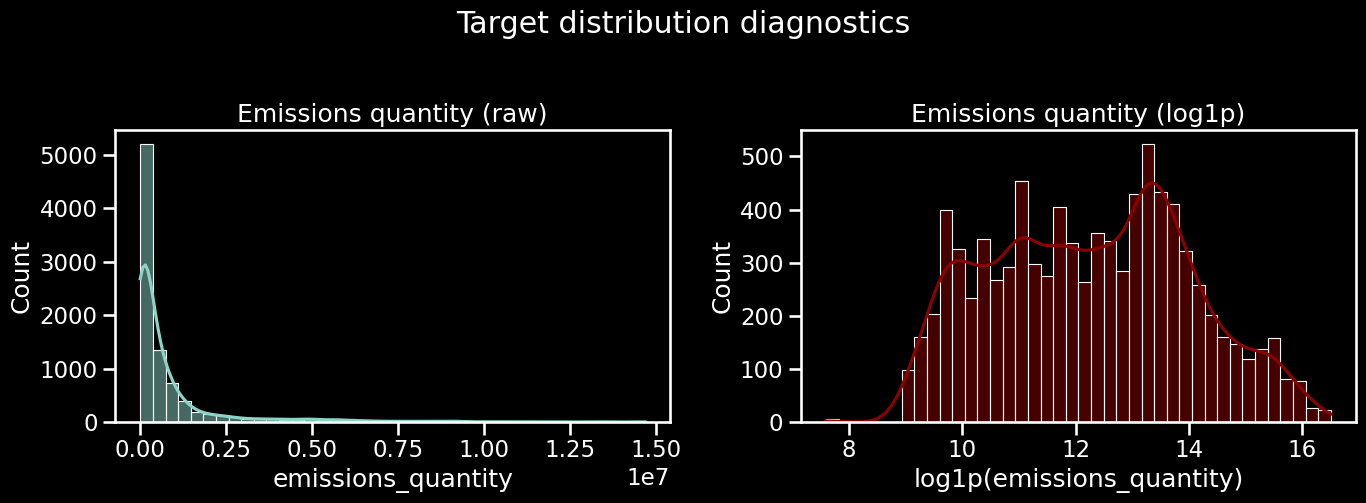

In [5]:
# Target distribution: raw and log1p for heavy tails
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['emissions_quantity'], bins=40, kde=True, ax=axes[0])
axes[0].set_title('Emissions quantity (raw)')
axes[0].set_xlabel('emissions_quantity')

sns.histplot(np.log1p(df['emissions_quantity']), bins=40, kde=True, ax=axes[1], color='darkred')
axes[1].set_title('Emissions quantity (log1p)')
axes[1].set_xlabel('log1p(emissions_quantity)')

fig.suptitle('Target distribution diagnostics', y=1.02)
plt.tight_layout()

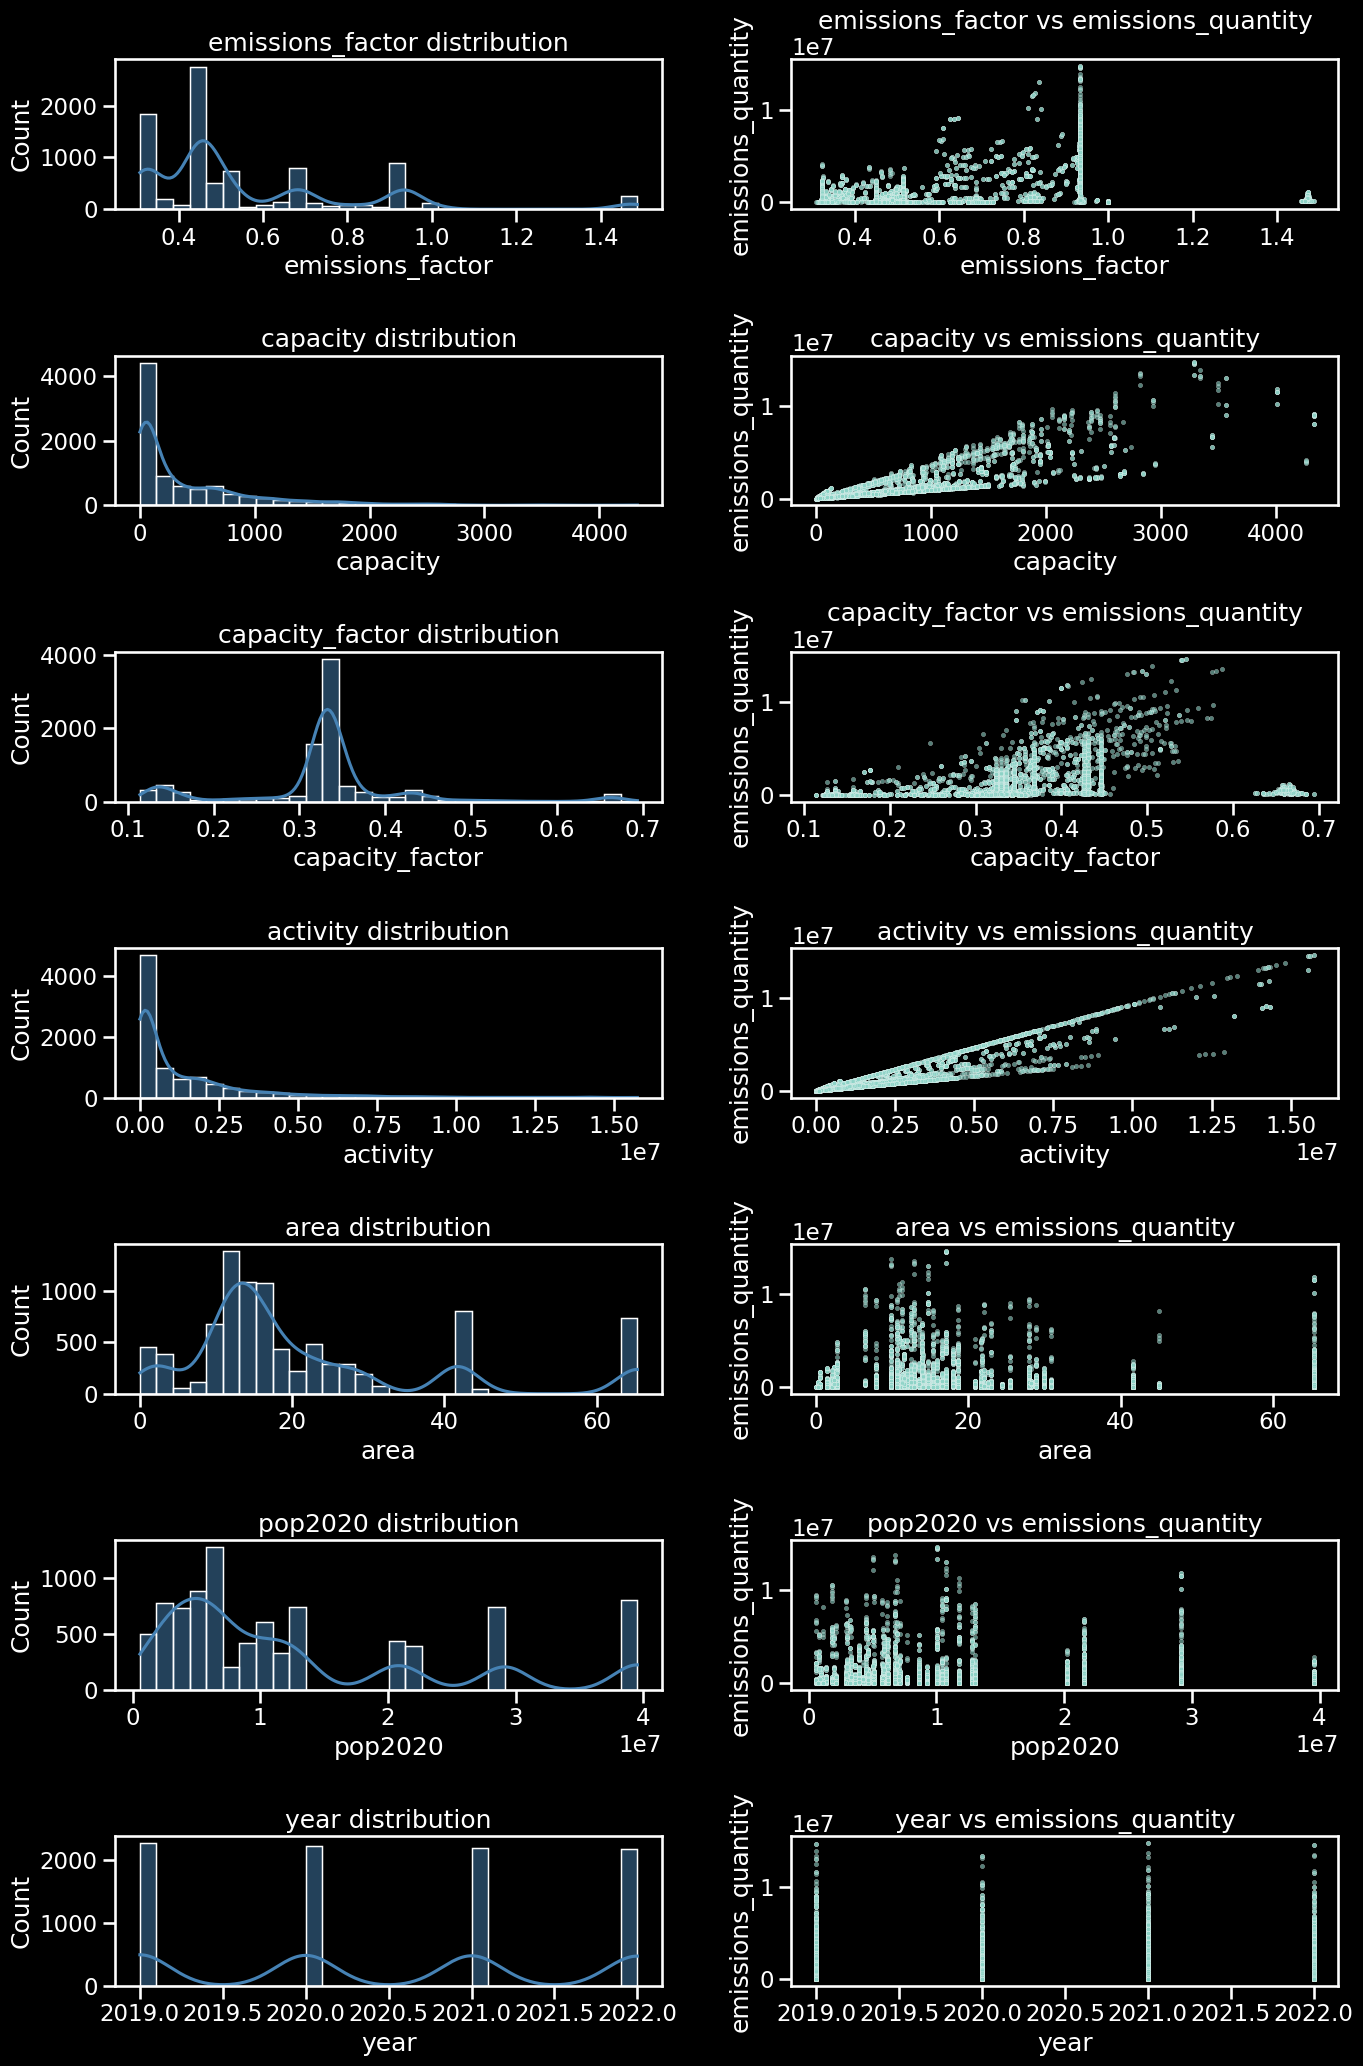

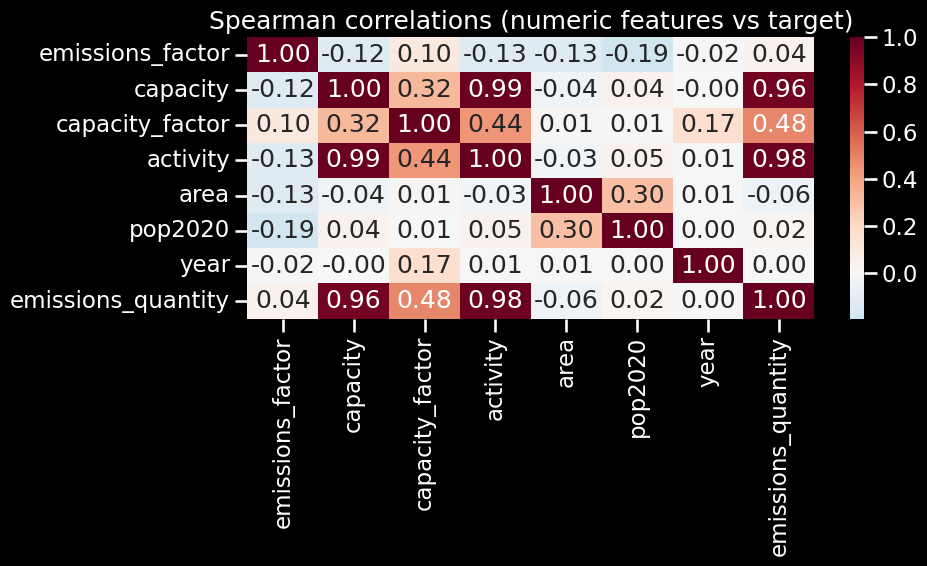

In [6]:
# Numeric feature distributions and Spearman correlations vs target
num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c]) and c != 'emissions_quantity']
fig, axes = plt.subplots(len(num_cols), 2, figsize=(14, 3 * len(num_cols)))
for idx, col in enumerate(num_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[idx, 0], color='steelblue')
    axes[idx, 0].set_title(f'{col} distribution')
    sns.scatterplot(x=df[col], y=df['emissions_quantity'], ax=axes[idx, 1], s=10, alpha=0.6)
    axes[idx, 1].set_title(f'{col} vs emissions_quantity')
    axes[idx, 1].set_xlabel(col)
plt.tight_layout()

corr = df[num_cols + ['emissions_quantity']].corr(method='spearman')
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Spearman correlations (numeric features vs target)')
plt.tight_layout()

In [7]:
cat_cols = [ c for c in df.columns if isinstance(df[c], pd.CategoricalDtype) ] 
# cat_cols = [c for c in df.columns if  pd.api.types.is_categorical_dtype(df[c])]
isinstance(df.columns[4], pd.CategoricalDtype)
cat_cols

[]

C:\Users\madhur\AppData\Local\Temp\ipykernel_12032\1816383305.py:2: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  cat_cols = [c for c in df.columns if  pd.api.types.is_categorical_dtype(df[c])]


,source_type,state
count,8849,8849
unique,6,49
top,gas,California
freq,5917,806


C:\Users\madhur\AppData\Local\Temp\ipykernel_12032\1816383305.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_cat = df.groupby('source_type')['emissions_quantity'].agg(['count','mean','median','sum']).sort_values('sum', ascending=False)


,count,mean,median,sum
source_type,,,,
coal,1045,3.321427e+06,2493000.0,3.470891e+09
gas,5917,5.076020e+05,227000.0,3.003481e+09
oil,1419,4.490599e+05,34000.0,6.372160e+08
waste,249,3.728353e+05,306000.0,9.283600e+07
other_fossil,142,2.606690e+05,61000.0,3.701500e+07
biomass,77,6.476623e+04,49000.0,4.987000e+06


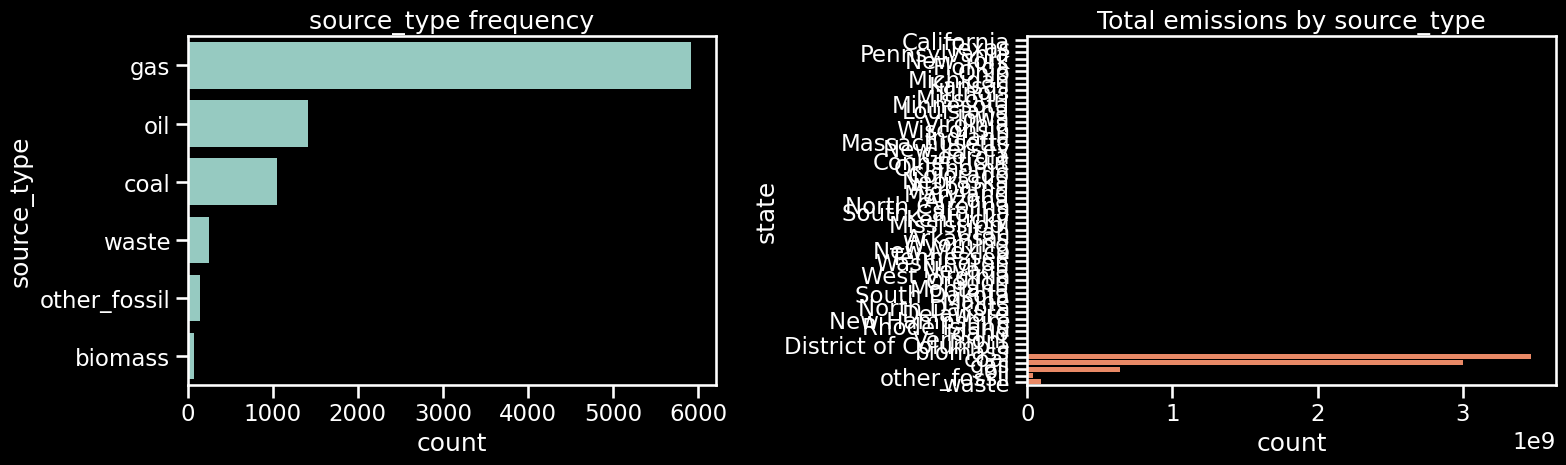

In [8]:
# Categorical structure and target by category
cat_cols = [c for c in df.columns if  pd.api.types.is_categorical_dtype(df[c])]
display(df[cat_cols].describe())

fig, axes = plt.subplots(1, len(cat_cols), figsize=(16, 5))
for idx, col in enumerate(cat_cols):
    sns.countplot(data=df, y=col, order=df[col].value_counts().index, ax=axes[idx])
    axes[idx].set_title(f'{col} frequency')
plt.tight_layout()

agg_cat = df.groupby('source_type')['emissions_quantity'].agg(['count','mean','median','sum']).sort_values('sum', ascending=False)
display(agg_cat.head(10))
sns.barplot(data=agg_cat.reset_index(), x='sum', y='source_type', color='coral')
plt.title('Total emissions by source_type')
plt.tight_layout()

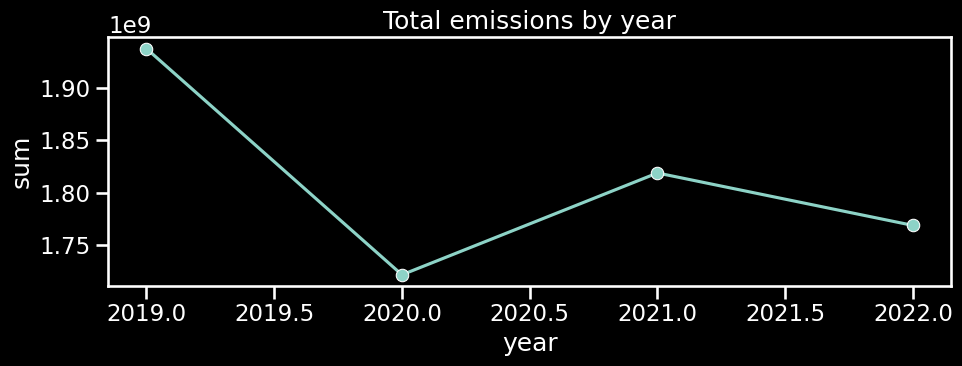

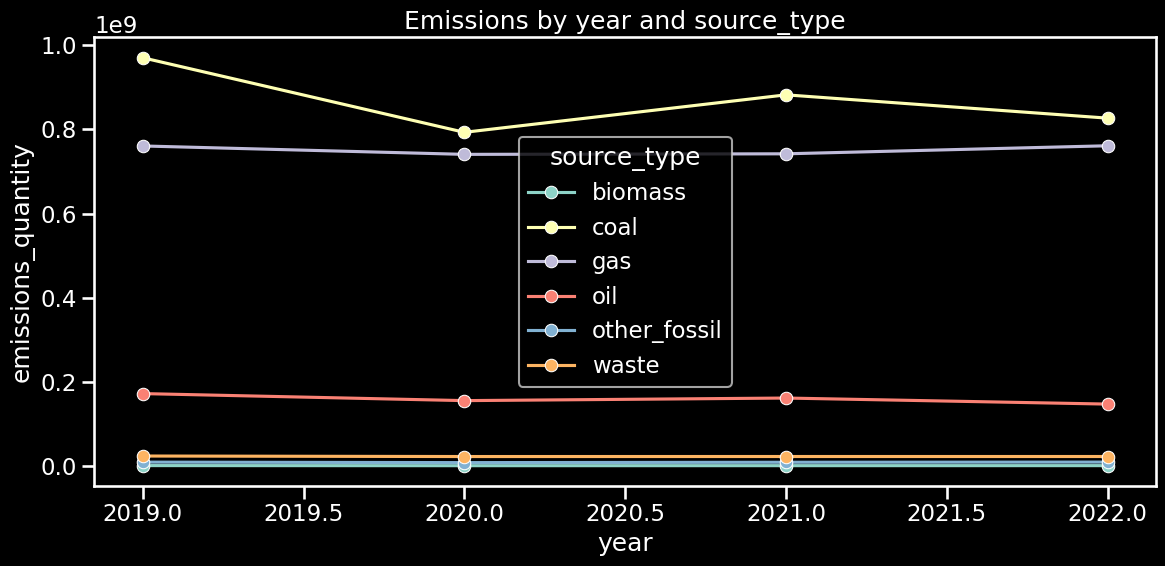

In [9]:
# Temporal trends by year (from start_time) and source_type
yearly = df_raw.groupby('year', dropna=False)['emissions_quantity'].agg(['count','sum','mean']).reset_index()
plt.figure(figsize=(10, 4))
sns.lineplot(data=yearly, x='year', y='sum', marker='o')
plt.title('Total emissions by year')
plt.tight_layout()

year_src = df_raw.groupby(['year','source_type'], dropna=False)['emissions_quantity'].sum().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=year_src, x='year', y='emissions_quantity', hue='source_type', marker='o')
plt.title('Emissions by year and source_type')
plt.tight_layout()

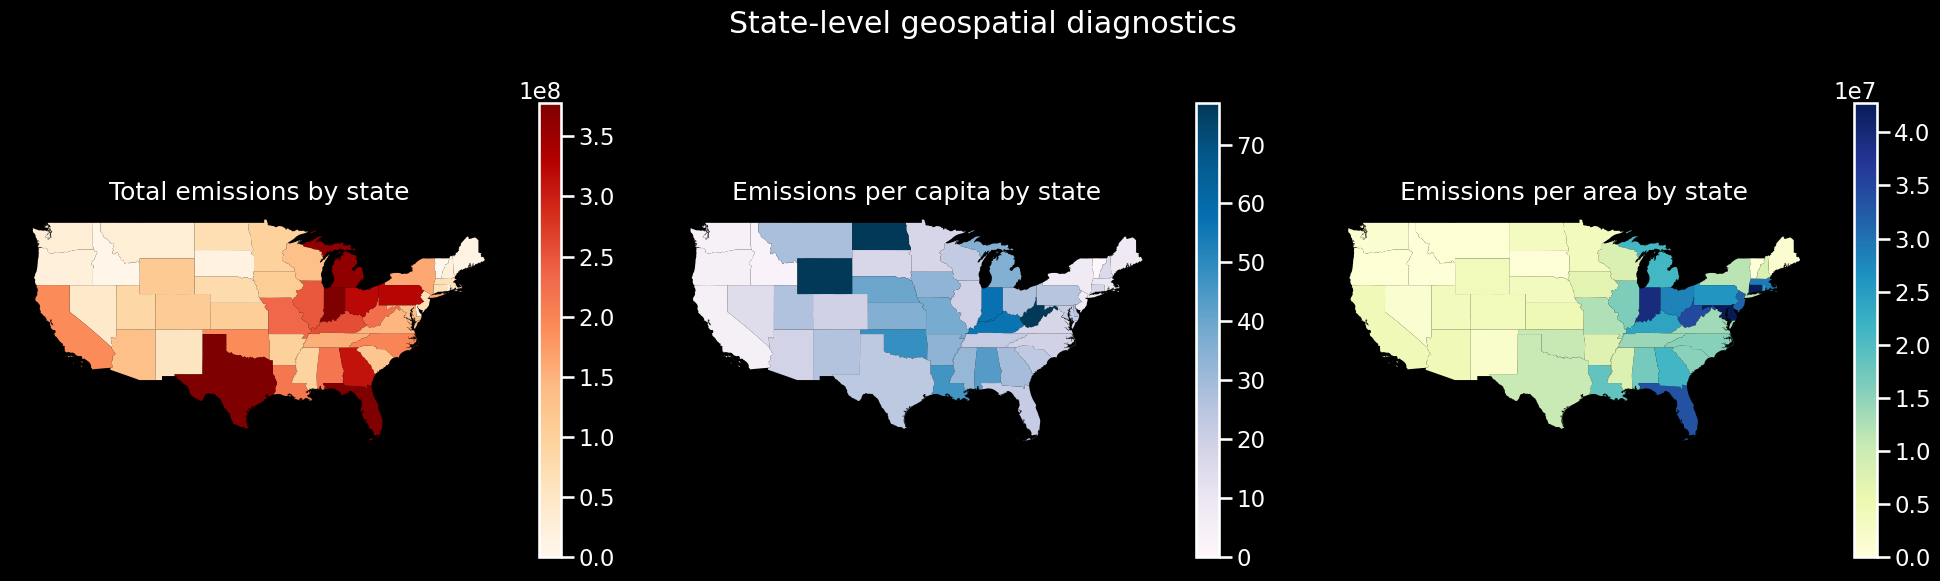

In [10]:
# Geospatial EDA: state-level choropleths (totals, per-capita, per-area)
usa_gdf = gpd.read_file(shpfile_path)
state_agg = (
    df_raw.groupby('state', dropna=False)
    .agg(emissions_quantity=('emissions_quantity','sum'),
         pop2020=('pop2020','mean'),
         area=('area','mean'))
    .reset_index()
 )
state_agg['emissions_per_capita'] = state_agg['emissions_quantity'] / state_agg['pop2020']
state_agg['emissions_per_area'] = state_agg['emissions_quantity'] / state_agg['area']
usa_plot = usa_gdf.merge(state_agg, left_on='NAME', right_on='state', how='left')

vmax_tot = usa_plot['emissions_quantity'].quantile(0.95)
vmax_cap = usa_plot['emissions_per_capita'].quantile(0.95)
vmax_area = usa_plot['emissions_per_area'].quantile(0.95)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
usa_plot.plot(column='emissions_quantity', cmap='OrRd', legend=True, ax=axes[0], vmin=0, vmax=vmax_tot)
axes[0].set_title('Total emissions by state')
usa_plot.plot(column='emissions_per_capita', cmap='PuBu', legend=True, ax=axes[1], vmin=0, vmax=vmax_cap)
axes[1].set_title('Emissions per capita by state')
usa_plot.plot(column='emissions_per_area', cmap='YlGnBu', legend=True, ax=axes[2], vmin=0, vmax=vmax_area)
axes[2].set_title('Emissions per area by state')
for ax in axes:
    ax.axis('off')
plt.suptitle('State-level geospatial diagnostics')
plt.tight_layout()

### Advanced EDA visuals
Additional diagnostics to assess distribution shape, multivariate structure, and spatiotemporal patterns relevant for modeling.

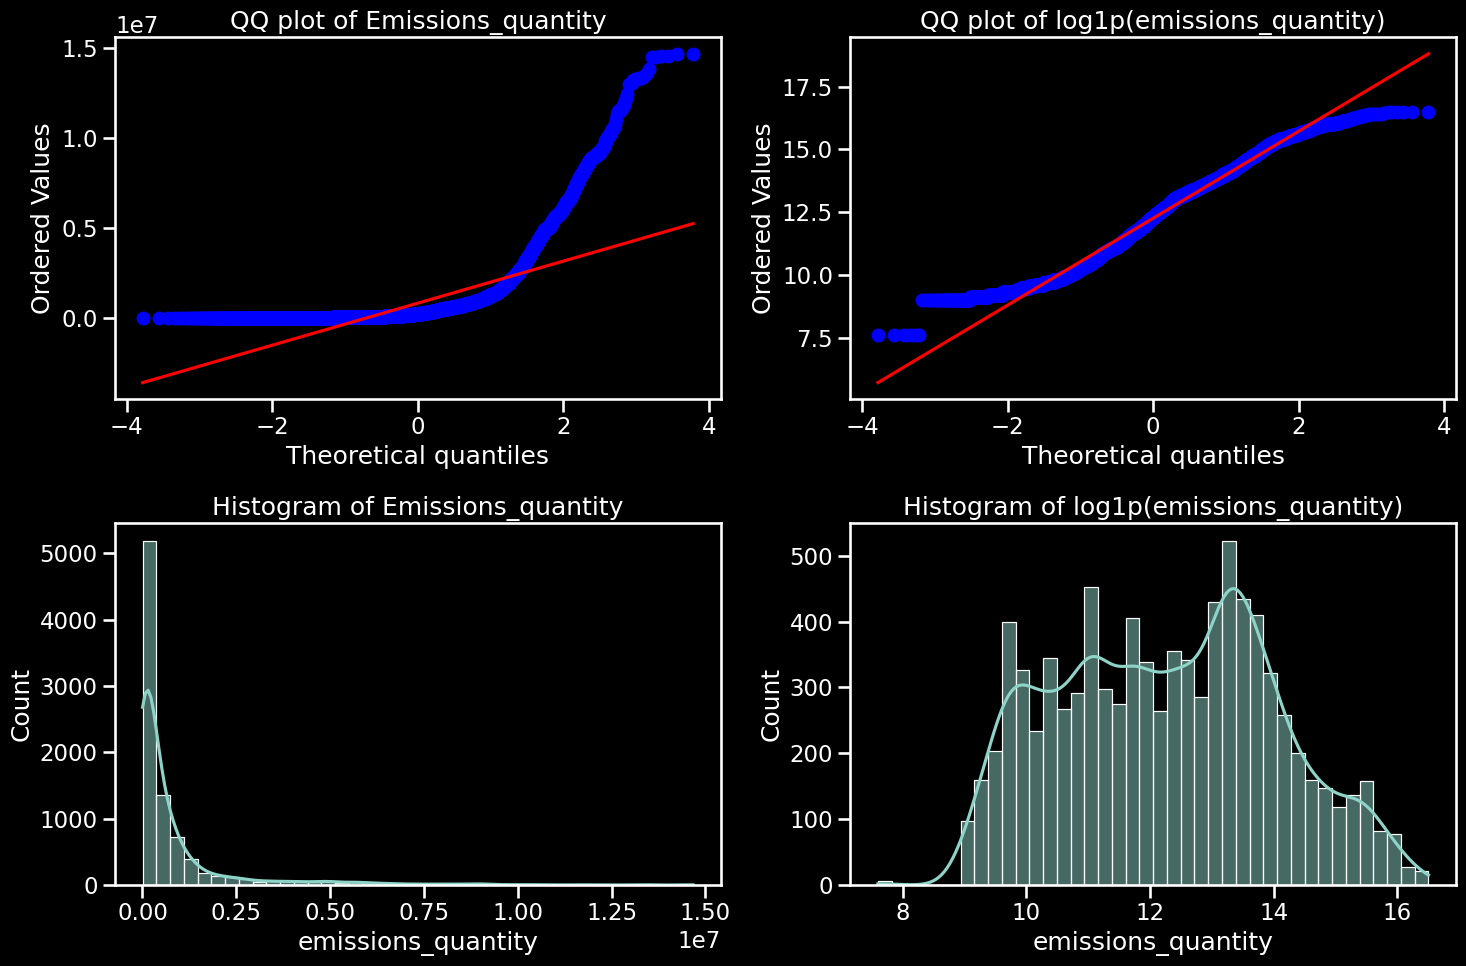

In [11]:
# QQ plot to assess tail heaviness of log1p(emissions_quantity)
from scipy import stats
# fig, ax = plt.subplots(figsize=(6, 6))
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

stats.probplot(df['emissions_quantity'], dist='norm', plot=ax[0][0] )
ax[0][0].set_title('QQ plot of Emissions_quantity')
stats.probplot(np.log1p(df['emissions_quantity']), dist='norm', plot=ax[0][1])
ax[0][1].set_title('QQ plot of log1p(emissions_quantity)')

## plot histogram for both
sns.histplot(df['emissions_quantity'], bins=40, kde=True, ax=ax[1][0] )
ax[1][0].set_title('Histogram of Emissions_quantity')
sns.histplot(np.log1p(df['emissions_quantity']), bins=40, kde=True, ax=ax[1][1] )
ax[1][1].set_title('Histogram of log1p(emissions_quantity)')


plt.tight_layout()

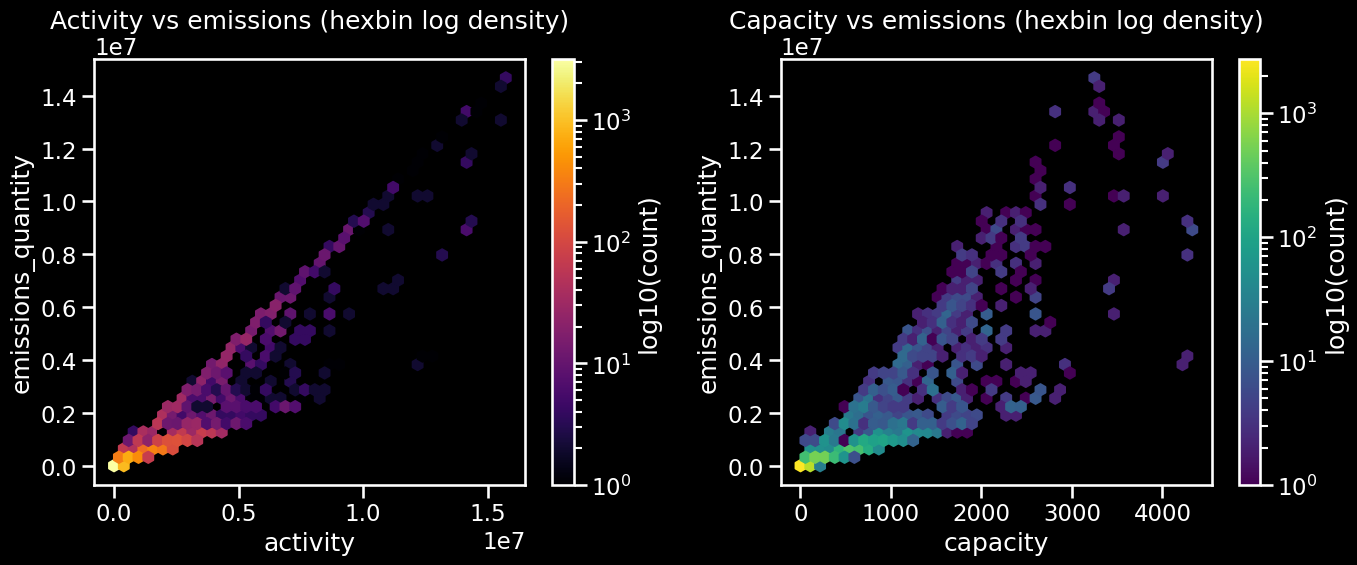

In [12]:
# Hexbin density to inspect nonlinear relationships (log color scale)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
hb1 = axes[0].hexbin(df['activity'], df['emissions_quantity'], gridsize=40, bins='log', cmap='inferno')
axes[0].set_xlabel('activity')
axes[0].set_ylabel('emissions_quantity')
axes[0].set_title('Activity vs emissions (hexbin log density)')
fig.colorbar(hb1, ax=axes[0], label='log10(count)')

hb2 = axes[1].hexbin(df['capacity'], df['emissions_quantity'], gridsize=40, bins='log', cmap='viridis')
axes[1].set_xlabel('capacity')
axes[1].set_ylabel('emissions_quantity')
axes[1].set_title('Capacity vs emissions (hexbin log density)')
fig.colorbar(hb2, ax=axes[1], label='log10(count)')
plt.tight_layout()

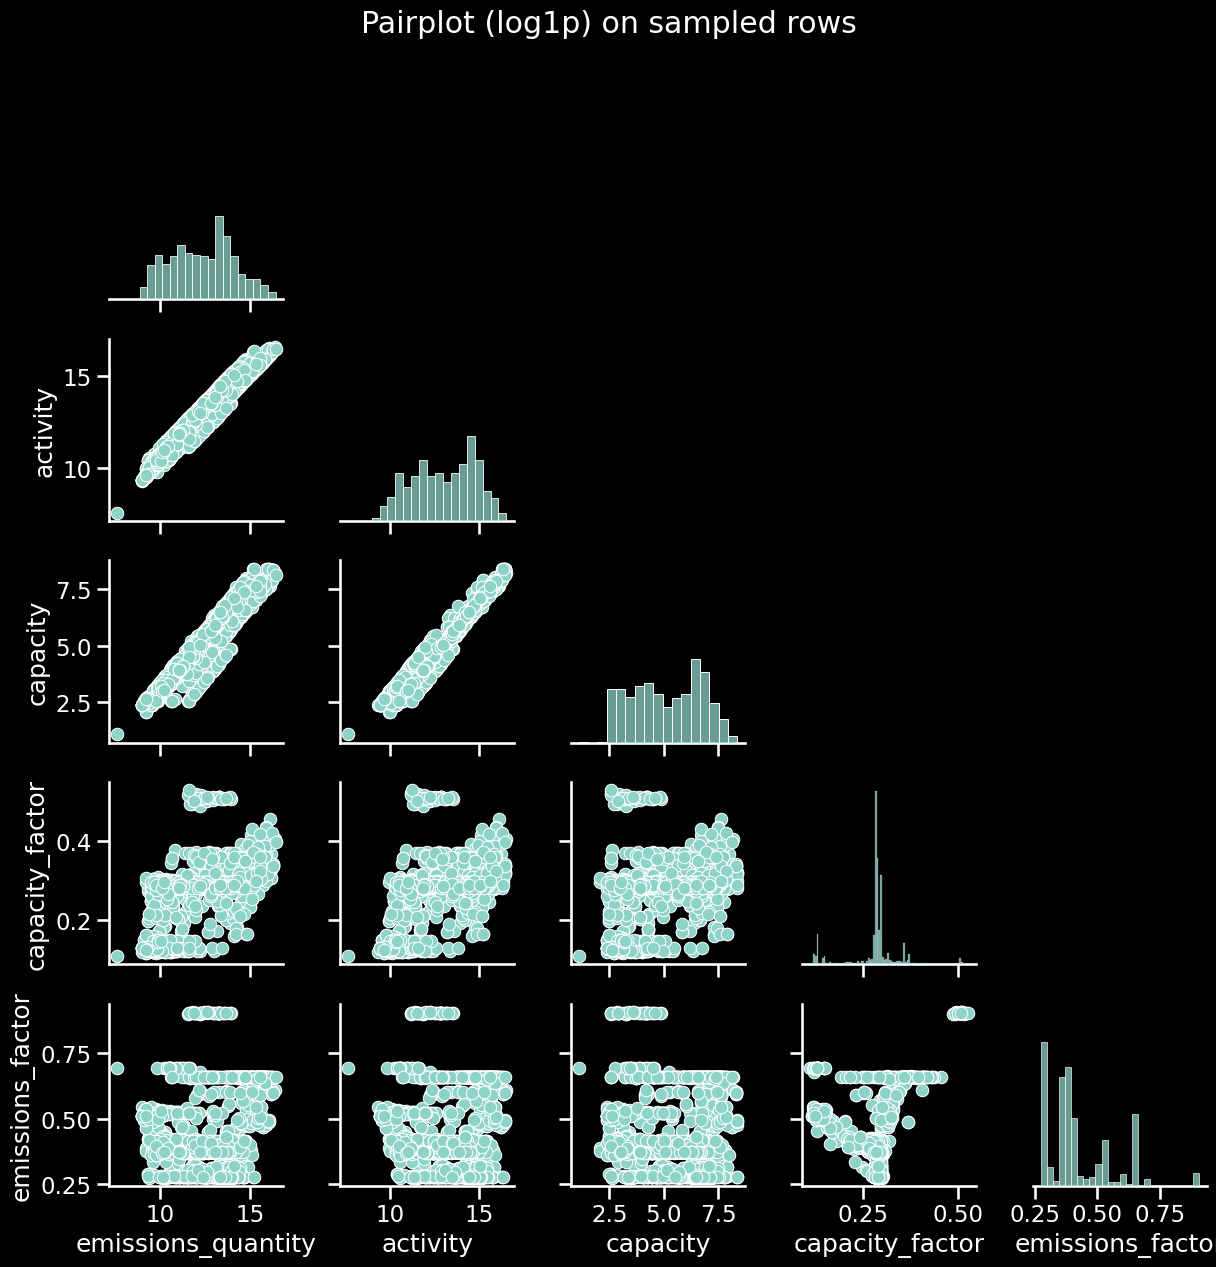

In [13]:
# Pairplot on log1p-transformed subset to visualize multivariate structure
plot_cols = ['emissions_quantity','activity','capacity','capacity_factor','emissions_factor']
sample_n = min(len(df), 2000)
pair_df = df[plot_cols].sample(n=sample_n, random_state=42).apply(np.log1p)
sns.pairplot(pair_df, diag_kind='hist', corner=True)
plt.suptitle('Pairplot (log1p) on sampled rows', y=1.02)
plt.tight_layout()

C:\Users\madhur\AppData\Local\Temp\ipykernel_12032\115695580.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=src_subset, y='source_type', x='log1p_emissions', order=top_src, palette='coolwarm')


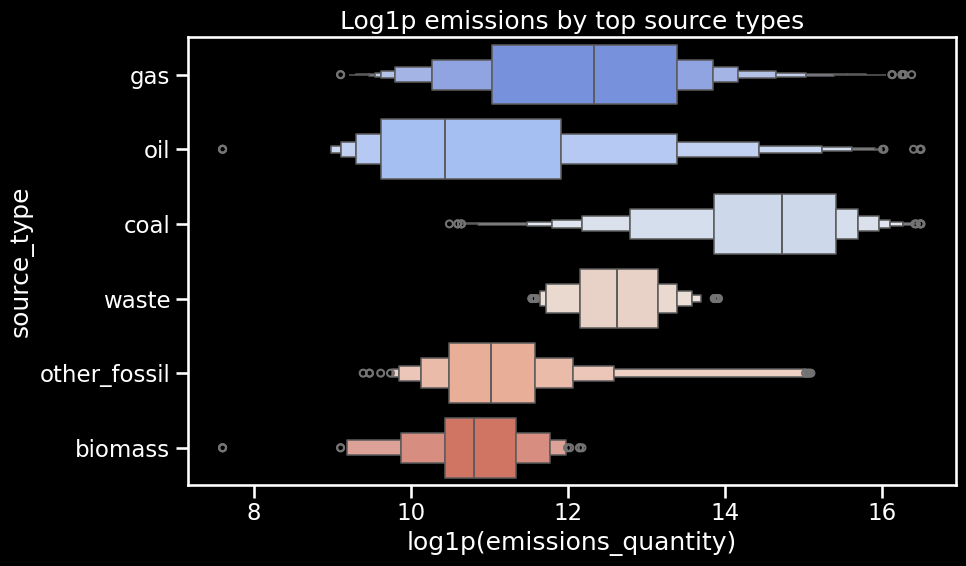

In [14]:
# Boxen plots of log1p(emissions_quantity) for top source types
top_src = df['source_type'].value_counts().head(8).index
src_subset = df[df['source_type'].isin(top_src)].copy()
src_subset['log1p_emissions'] = np.log1p(src_subset['emissions_quantity'])
plt.figure(figsize=(10, 6))
sns.boxenplot(data=src_subset, y='source_type', x='log1p_emissions', order=top_src, palette='coolwarm')
plt.title('Log1p emissions by top source types')
plt.xlabel('log1p(emissions_quantity)')
plt.ylabel('source_type')
plt.tight_layout()

Decision: `log1p(emissions_quantity)` improves symmetry; the model target should be log-transformed


### Modeling-oriented feature view
 feature set (log-transformed where needed) for quick multivariate observation

In [16]:
df.head()

,emissions_quantity,emissions_factor,capacity,capacity_factor,activity,source_type,state,area,pop2020,year
0,214000.0,0.513,138.0,0.345,417000.0,gas,Alabama,12.899239,5024279.0,2022
1,204000.0,0.513,138.0,0.329,398000.0,gas,Alabama,12.899239,5024279.0,2019
2,209000.0,0.515,138.0,0.335,406000.0,gas,Alabama,12.899239,5024279.0,2020
3,201000.0,0.513,138.0,0.324,392000.0,gas,Alabama,12.899239,5024279.0,2021
4,113000.0,0.452,87.0,0.328,250000.0,gas,Texas,65.363350,29145505.0,2019


In [ ]:
# Build engineered feature set for inspection
feat_df = (
    (   pd.DataFrame(   {
            'y_log': np.log1p(df['emissions_quantity']),
            'activity_log': np.log1p(df['activity']),
            'capacity_log': np.log1p(df['capacity']),
            'capacity_factor': df['capacity_factor'],
            'emissionsFactor_log': np.log1p(df['emissions_factor']),
            'pop2020_log': np.log1p(df['pop2020']),
            'area_log': np.log1p(df['area']),
            'activity_per_capacity': df['activity'] / df['capacity'],
            'activity_per_capita': df['activity'] / df['pop2020'],
            'activity_per_area': df['activity'] / df['area'],
            'capacity_per_capita': df['capacity'] / df['pop2020'],
            'capacity_per_area': df['capacity'] / df['area'],
            'capacity_CapacityFact': df['capacity_factor'] * np.log1p(df['capacity']),
            'utilization_ratio': df['activity'] / (df['capacity_CapacityFact'] + ),


                        }
                    )
    )
)
feat_df.replace([np.inf, -np.inf], np.nan, inplace=True)
feat_df.dropna(inplace=True)
feat_df.head()

,y_log,activity_log,capacity_log,capacity_factor,emissionsFactor_log,pop2020_log,area_log,activity_per_capacity,activity_per_capita,activity_per_area,capacity_per_capita,capacity_per_area,capacity_CapacityFact
0,12.273736,12.940844,4.934474,0.345,0.414094,15.429793,2.631834,3021.739130,0.082997,32327.489578,0.000027,10.698306,1.702394
1,12.225880,12.894210,4.934474,0.329,0.414094,15.429793,2.631834,2884.057971,0.079215,30854.534417,0.000027,10.698306,1.623442
2,12.250094,12.914111,4.934474,0.335,0.415415,15.429793,2.631834,2942.028986,0.080808,31474.726064,0.000027,10.698306,1.653049
3,12.211065,12.879020,4.934474,0.324,0.414094,15.429793,2.631834,2840.579710,0.078021,30389.390682,0.000027,10.698306,1.598770
4,11.635152,12.429220,4.477337,0.328,0.372942,17.187811,4.195145,2873.563218,0.008578,3824.773392,0.000003,1.331021,1.468566


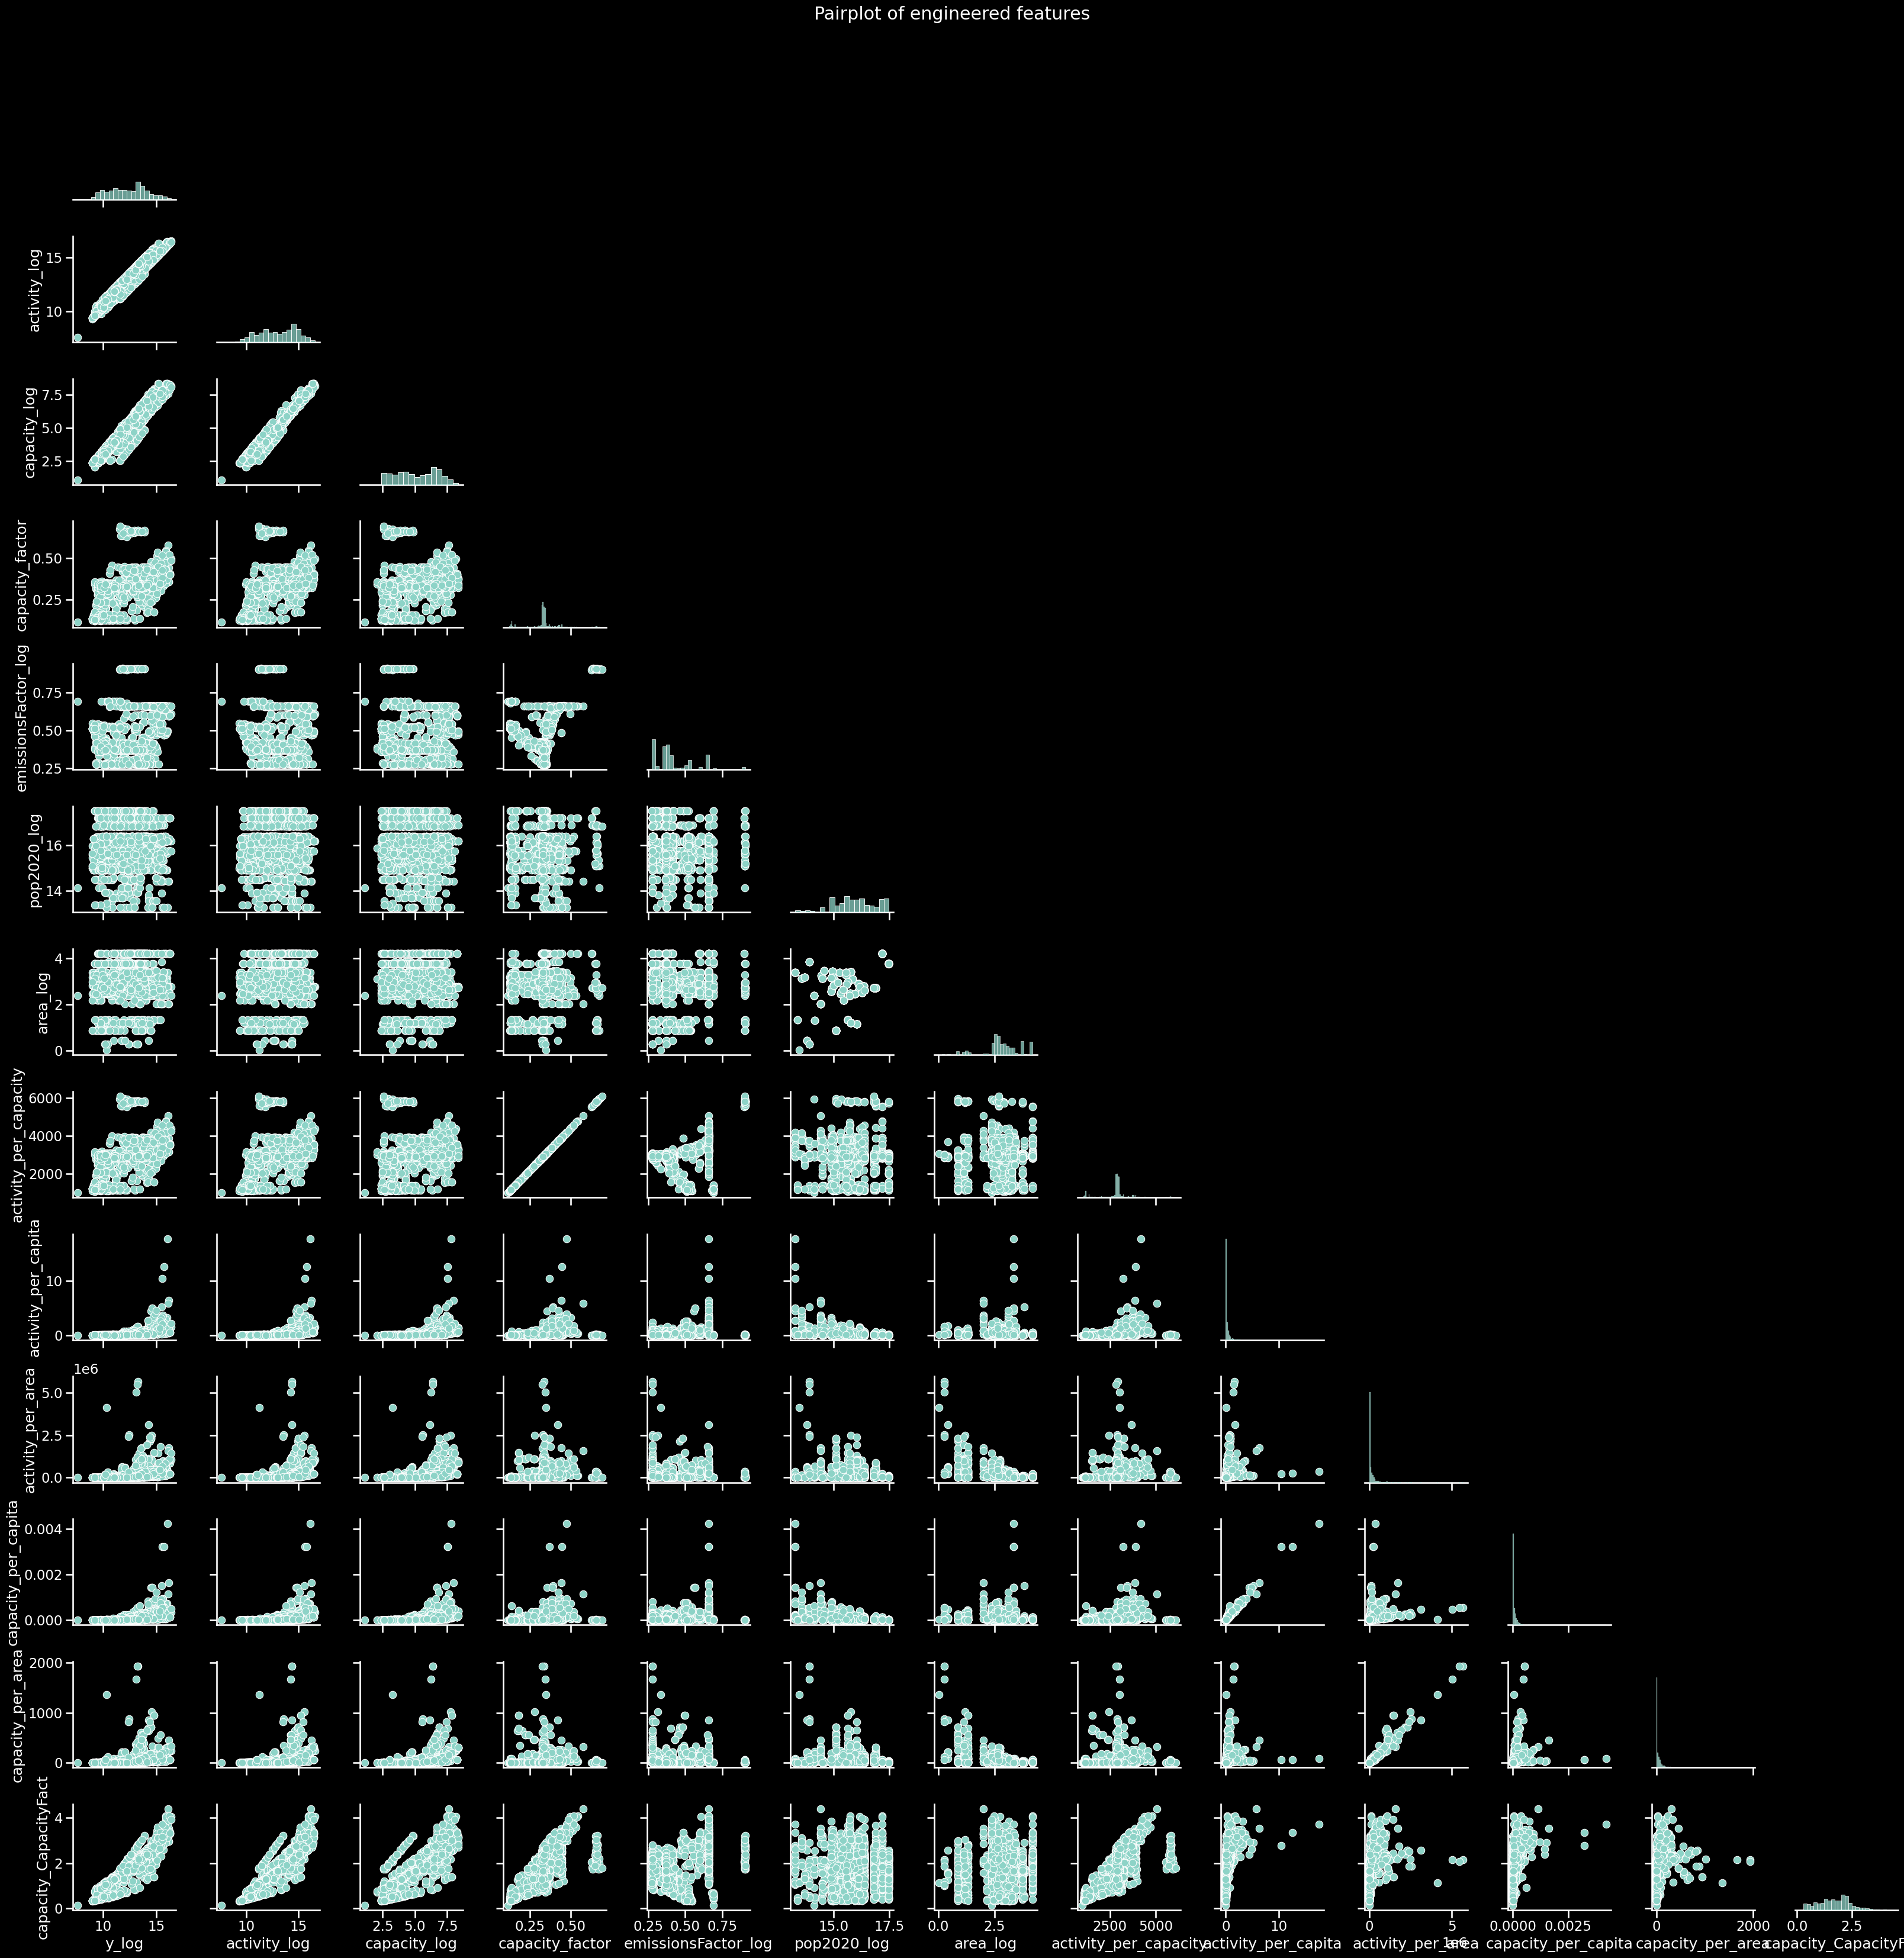

In [17]:
# Pairplot on engineered features (sampled for speed)
pair_sample = feat_df.sample(n=min(len(feat_df), 2000), random_state=42)
sns.pairplot(pair_sample, diag_kind='hist', corner=True)
plt.suptitle('Pairplot of engineered features', y=1.02)
plt.tight_layout()

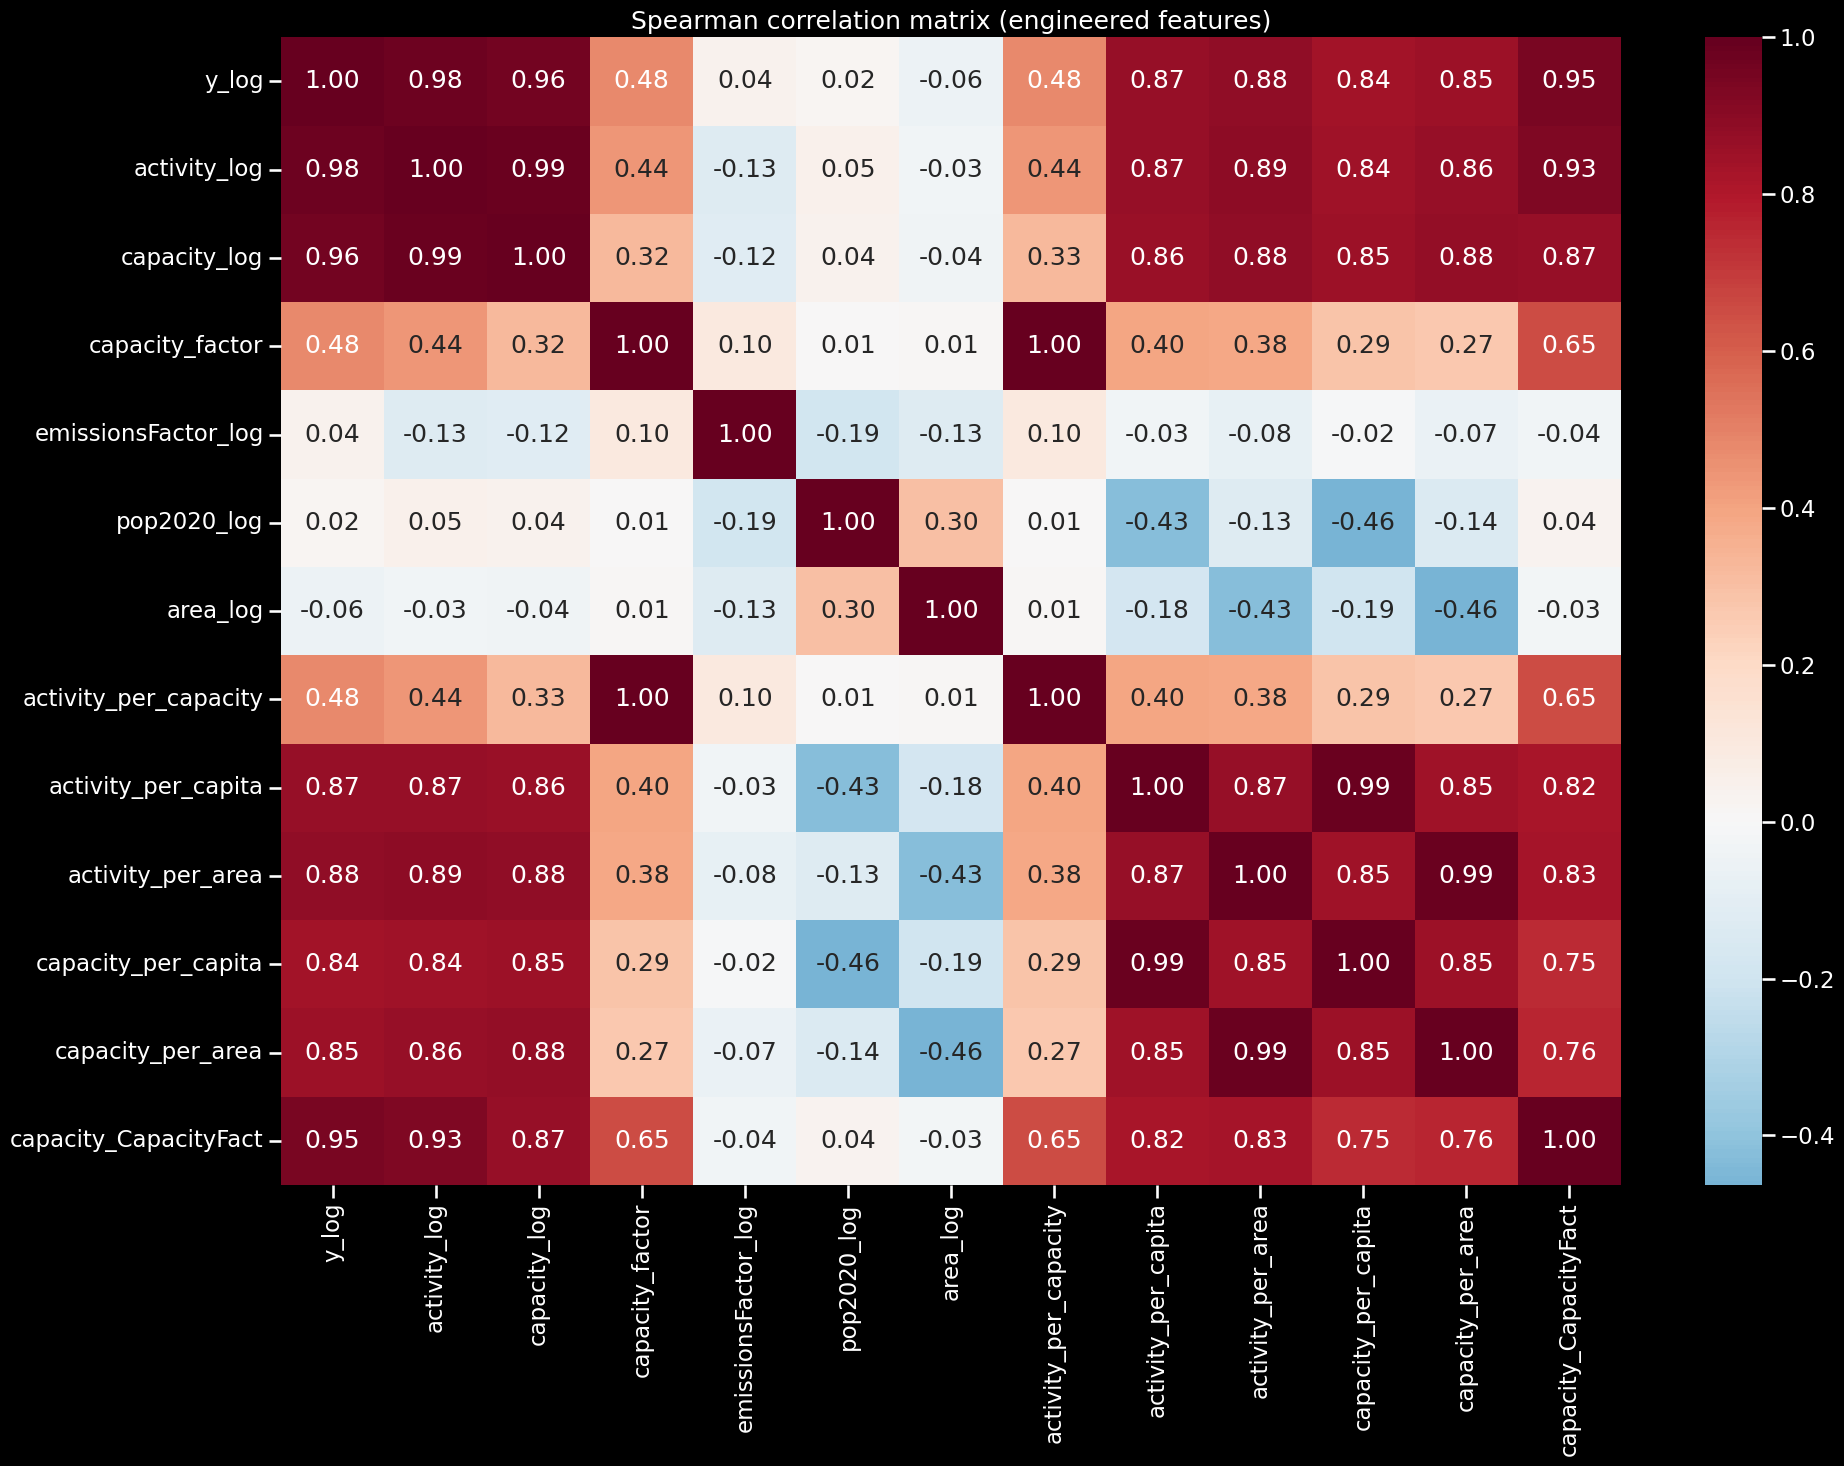

In [18]:
# Correlation matrix on engineered features
corr_feat = feat_df.corr(method='spearman')
plt.figure( figsize= (20,15) )
sns.heatmap( corr_feat, annot= True, fmt= '.2f', cmap= 'RdBu_r', center= 0 )
plt.title( 'Spearman correlation matrix (engineered features)' )
plt.tight_layout()

In [ ]:
### debug  engineer script

In [1]:
import pandas as pd
import pathlib
import numpy as np

In [2]:
input_file = pathlib.Path( '../data/processed/processed_data.csv' )

In [ ]:
from features import engineer
import sklearn as skl
df = pd.read_csv( input_file )
df_featured = engineer.create_features( df )
df_featured


def create_preprocessor():
    """Create a preprocessing pipeline."""
    # Define feature groups
    cat_col_ls = ['state', 'source_type', 'inter']
    # Preprocessing for categorical features
    categorical_transformer = skl.pipeline.Pipeline(
        steps= [  (  'onehot', skl.preprocessing.OneHotEncoder( handle_unknown='ignore', sparse_output= True )  ),
               ]
    )
    
    preprocessor = skl.compose.ColumnTransformer(
        transformers= [     (  'cat', categorical_transformer, cat_col_ls  ),
                      ]
    )
    

    return preprocessor



# Create and fit the preprocessor

preprocessor = create_preprocessor()

xx = df_featured.drop( columns= ['emissions_quantity'] , errors= 'ignore' )  # Features only
yy = df_featured['emissions_quantity']  # Target variable

## features remaining after one-hot encoding categorical variables
REMAINING_Features_ls = [        
    'capacity', 'capacity_factor', 'activity',
    'area', 'pop2020',
    'log1p_activity', 'log1p_capacity', 'log1p_pop2020', 'log1p_area',
    'log1Pop_density', 'activity_per_capita', 'activity_per_area',
    'capacity_per_capita', 'capacity_density', 'potential_output',
    'utilization_ratio', 'activity_capacityFactor', 'activity_per_capacity',
    'activity_capacity', 'capacity_factor_capacity',
]

xx_remainingFeatures_df = xx.filter( REMAINING_Features_ls )
xx_remainingFeatures_df

2026-01-08 12:39:45,513 - feature-engineering - INFO - Creating new features


2026-01-08 12:39:45,597 - feature-engineering - INFO - Created 1.transforms + ratios  2.power-system structure  3. Interaction features. Next One Hot Encoding


,capacity,capacity_factor,activity,area,pop2020,log1p_activity,log1p_capacity,log1p_pop2020,log1p_area,log1Pop_density,activity_per_capita,activity_per_area,capacity_per_capita,capacity_density,potential_output,utilization_ratio,activity_capacityFactor,activity_per_capacity,activity_capacity,capacity_factor_capacity
0,138.0,0.345,417000.0,12.899239,5024279.0,12.940844,4.934474,15.429793,2.631834,12.872627,0.082997,32327.489578,0.000027,10.698306,47.610,8758.664146,143865.0,3021.739130,2.057676e+06,1.702394
1,138.0,0.329,398000.0,12.899239,5024279.0,12.894210,4.934474,15.429793,2.631834,12.872627,0.079215,30854.534417,0.000027,10.698306,45.402,8766.133650,130942.0,2884.057971,1.963921e+06,1.623442
2,138.0,0.335,406000.0,12.899239,5024279.0,12.914111,4.934474,15.429793,2.631834,12.872627,0.080808,31474.726064,0.000027,10.698306,46.230,8782.176076,136010.0,2942.028986,2.003396e+06,1.653049
3,138.0,0.324,392000.0,12.899239,5024279.0,12.879020,4.934474,15.429793,2.631834,12.872627,0.078021,30389.390682,0.000027,10.698306,44.712,8767.221328,127008.0,2840.579710,1.934314e+06,1.598770
4,87.0,0.328,250000.0,65.363350,29145505.0,12.429220,4.477337,17.187811,4.195145,13.007852,0.008578,3824.773392,0.000003,1.331021,28.536,8760.863471,82000.0,2873.563218,1.119334e+06,1.468566
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8844,1267.0,0.345,3830000.0,17.081225,10077331.0,15.158376,7.145196,16.125799,2.894874,13.287821,0.380061,224222.790343,0.000126,74.175007,437.115,8761.996271,1321350.0,3022.888713,2.736610e+07,2.465093
8845,35.0,0.323,99000.0,17.081225,10077331.0,11.502885,3.583519,16.125799,2.894874,13.287821,0.009824,5795.837139,0.000003,2.049033,11.305,8757.187085,31977.0,2828.571429,3.547684e+05,1.157477
8846,35.0,0.329,101000.0,17.081225,10077331.0,11.522886,3.583519,16.125799,2.894874,13.287821,0.010022,5912.924758,0.000003,2.049033,11.515,8771.168042,33229.0,2885.714286,3.619354e+05,1.178978
8847,35.0,0.335,103000.0,17.081225,10077331.0,11.542494,3.583519,16.125799,2.894874,13.287821,0.010221,6030.012377,0.000003,2.049033,11.725,8784.648188,34505.0,2942.857143,3.691025e+05,1.200479


In [129]:
## get one-hot encoded feature names
ohe = preprocessor.named_transformers['cat'].named_steps['onehot']

# ohe

AttributeError: 'ColumnTransformer' object has no attribute 'named_transformers'

In [128]:
ohe_names = ohe.get_feature_names_out(preprocessor.transformers[0][2])
ohe_names

array(['state_Alabama', 'state_Arizona', 'state_Arkansas',
       'state_California', 'state_Colorado', 'state_Connecticut',
       'state_Delaware', 'state_DistrictofColumbia', 'state_Florida',
       'state_Georgia', 'state_Idaho', 'state_Illinois', 'state_Indiana',
       'state_Iowa', 'state_Kansas', 'state_Kentucky', 'state_Louisiana',
       'state_Maine', 'state_Maryland', 'state_Massachusetts',
       'state_Michigan', 'state_Minnesota', 'state_Mississippi',
       'state_Missouri', 'state_Montana', 'state_Nebraska',
       'state_Nevada', 'state_NewHampshire', 'state_NewJersey',
       'state_NewMexico', 'state_NewYork', 'state_NorthCarolina',
       'state_NorthDakota', 'state_Ohio', 'state_Oklahoma',
       'state_Oregon', 'state_Pennsylvania', 'state_RhodeIsland',
       'state_SouthCarolina', 'state_SouthDakota', 'state_Tennessee',
       'state_Texas', 'state_Utah', 'state_Vermont', 'state_Virginia',
       'state_Washington', 'state_WestVirginia', 'state_Wisconsin',
    

In [ ]:
## Fit and transform (OHE) the data
x_transformed = preprocessor.fit_transform( xx )
## If result is sparse, make dense
x_arr = x_transformed.toarray() if hasattr( x_transformed, 'toarray' )  else x_transformed

xCat_transformed_df = pd.DataFrame(x_arr)  ## <-- only catorical features after transformation

print( f"""The last number of the categorical-trasnformed column is --> {len(xCat_transformed_df.columns)-1}
Thus we begin naming xx_remainingFeatures_df starting from  --> {len(xCat_transformed_df.columns)}""" )


## renamed columns of xx_remainingFeatures_df using continue number
contd_col_nm = np.arange(  len(xCat_transformed_df.columns), len(xCat_transformed_df.columns) + len(xx_remainingFeatures_df.columns)  ).tolist()
xx_remainingFeatures_df.columns = contd_col_nm

### this order is to be followed, dont mess it, as the column names will be arranged in this order
DF_ORDER: list = [  xCat_transformed_df , xx_remainingFeatures_df, df_featured[['emissions_quantity']]  ]
engineered_col: list = ohe_names.tolist() + REMAINING_Features_ls +  [ 'emissions_quantity' ]

engineered_df = pd.concat( DF_ORDER, axis= 1 )

The last number of the categorical-trasnformed column is --> 229
Thus we begin naming xx_remainingFeatures_df starting from  --> 230


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,emissions_quantity
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,138.0,0.345,417000.0,12.899239,5024279.0,12.940844,4.934474,15.429793,2.631834,12.872627,0.082997,32327.489578,0.000027,10.698306,47.610,8758.664146,143865.0,3021.739130,2.057676e+06,1.702394,214000.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,138.0,0.329,398000.0,12.899239,5024279.0,12.894210,4.934474,15.429793,2.631834,12.872627,0.079215,30854.534417,0.000027,10.698306,45.402,8766.133650,130942.0,2884.057971,1.963921e+06,1.623442,204000.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.

The last number of the categorical-trasnformed column is --> 229
Thus we begin naming xx_remainingFeatures_df starting from  --> 230


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,emissions_quantity
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,138.0,0.345,417000.0,12.899239,5024279.0,12.940844,4.934474,15.429793,2.631834,12.872627,0.082997,32327.489578,0.000027,10.698306,47.610,8758.664146,143865.0,3021.739130,2.057676e+06,1.702394,214000.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,138.0,0.329,398000.0,12.899239,5024279.0,12.894210,4.934474,15.429793,2.631834,12.872627,0.079215,30854.534417,0.000027,10.698306,45.402,8766.133650,130942.0,2884.057971,1.963921e+06,1.623442,204000.0
